In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pickle
import yaml
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sys
import os
sys.path.insert(0, '../')
from src.models import build_rnn_model,build_lstm_model
from src.tf_dataset_loader import create_train_valid_test_datasets
from src.training import train_model
from src.preprocessing import load_arrays

In [3]:
with open('../config.yaml','r') as f:
    config=yaml.safe_load(f)
    
print('Config loaded:')
print(f"Lookback: {config['DATA']['lookback_window']}")
print(f"Batch size: {config['TRAINING']['batch_size']}")
print(f"Epochs: {config['TRAINING']['epochs']}")

Config loaded:
Lookback: 60
Batch size: 32
Epochs: 100


In [4]:
X_train,X_valid,X_test,y_train,y_valid,y_test,scaler=load_arrays(folder="../data/processed")
    
print(f'Data shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_valid: {X_valid.shape}, y_valid: {y_valid.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

Data shapes:
X_train: (2599, 60, 1), y_train: (2599, 1)
X_valid: (556, 60, 1), y_valid: (556, 1)
X_test: (558, 60, 1), y_test: (558, 1)


**Create datasets**

In [5]:
train_ds,valid_ds,test_ds=create_train_valid_test_datasets(
    X_train=X_train,y_train=y_train,
    X_valid=X_valid,y_valid=y_valid,
    X_test=X_test,y_test=y_test,
    config=config
)

print('Datasets created')
print(f'train_ds: {train_ds}')
print(f'valid_ds: {valid_ds}')
print(f'test_ds: {test_ds}')

Datasets created
train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>
valid_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>
test_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>


**Build Models**

In [6]:
input_shape=(config["DATA"]["lookback_window"],1)

In [7]:
rnn_model=build_rnn_model(config,input_shape)
rnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
lstm_model=build_lstm_model(config,input_shape)

In [9]:
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (RNN)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_3 (RNN)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

**Train RNN**

In [10]:
rnn_history, rnn_time = train_model(
    rnn_model, 
    train_ds, 
    valid_ds, 
    config,
    '../models/rnn_model.keras'
)

print(f'RNN training complete in {rnn_time:.2f}s')

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - loss: 0.0077 - mae: 0.0557 - val_loss: 3.8425e-04 - val_mae: 0.0154
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - loss: 0.0019 - mae: 0.0252 - val_loss: 5.1322e-04 - val_mae: 0.0181
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 0.0013 - mae: 0.0200 - val_loss: 1.7545e-04 - val_mae: 0.0098
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 8.3697e-04 - mae: 0.0162 - val_loss: 1.3968e-04 - val_mae: 0.0083
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 7.7851e-04 - mae: 0.0152 - val_loss: 1.2006e-04 - val_mae: 0.0076
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 7.0571e-04 - mae: 0.0143 - val_loss: 2.8177e-04 - val_mae: 0.0143
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 6.3169e-04 - mae: 0.0138 - val_loss: 1.0446e-04 - val_mae: 0.0071
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 5.7009e-04 - mae: 0.0137 - val_loss: 1.2607e-04 - val_mae: 0.0082
Ep

**Train LSTM**

In [11]:
lstm_history,lstm_time=train_model(
    lstm_model,
    train_ds,
    valid_ds,
    config,
    '../models/lstm_model.keras'
)

print(f'LSTM training complete in {lstm_time:.2f}s')

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - loss: 0.0086 - mae: 0.0516 - val_loss: 7.7965e-04 - val_mae: 0.0256
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - loss: 8.3406e-04 - mae: 0.0143 - val_loss: 1.9526e-04 - val_mae: 0.0102
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - loss: 6.4330e-04 - mae: 0.0134 - val_loss: 1.8452e-04 - val_mae: 0.0100
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 5.9328e-04 - mae: 0.0126 - val_loss: 2.7331e-04 - val_mae: 0.0130
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 6.0092e-04 - mae: 0.0134 - val_loss: 1.8183e-04 - val_mae: 0.0096
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 6.0807e-04 - mae: 0.0134 - val_loss: 1.4482e-04 - val_mae: 0.0083
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 4.8296e-04 - mae: 0.0121 - val_loss: 1.9874e-04 - val_mae: 0.0108
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 4.5460e-04 - mae: 0.0116 - val_loss: 1.2653e-04 - val_mae: 0.

In [14]:
history_dir='../results/history/'
os.makedirs(history_dir,exist_ok=True)
with open(f'{history_dir}rnn_training_history.pkl', 'wb') as f:
    pickle.dump(rnn_history.history, f)

with open(f'{history_dir}lstm_training_history.pkl', 'wb') as f:
    pickle.dump(lstm_history.history, f)

**Plot training history**

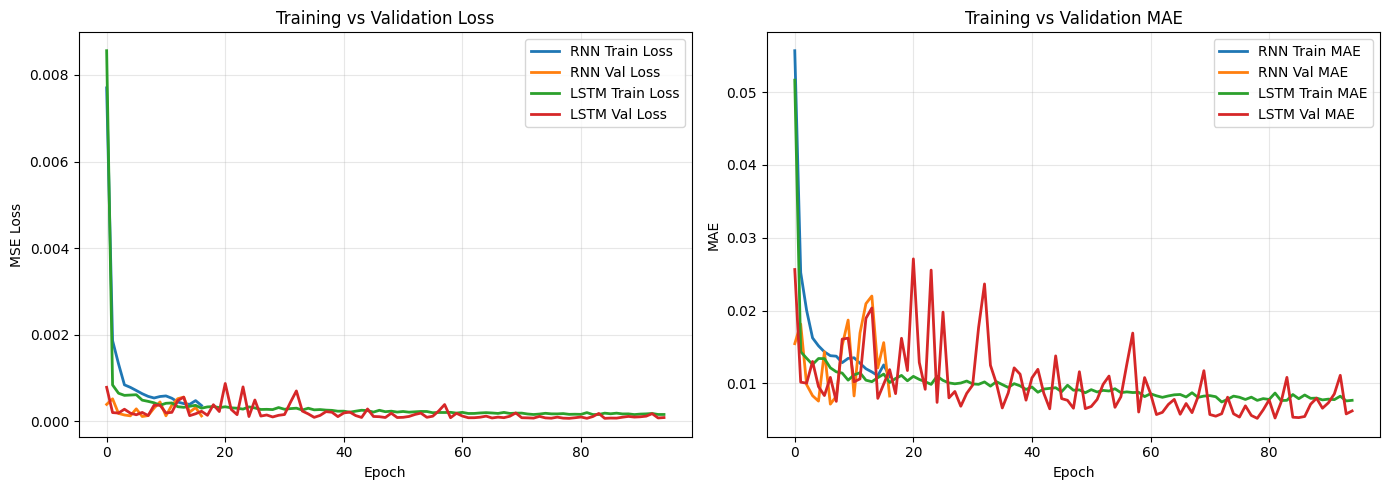

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(rnn_history.history['loss'], label='RNN Train Loss', linewidth=2)
axes[0].plot(rnn_history.history['val_loss'], label='RNN Val Loss', linewidth=2)
axes[0].plot(lstm_history.history['loss'], label='LSTM Train Loss', linewidth=2)
axes[0].plot(lstm_history.history['val_loss'], label='LSTM Val Loss', linewidth=2)
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE curves
axes[1].plot(rnn_history.history['mae'], label='RNN Train MAE', linewidth=2)
axes[1].plot(rnn_history.history['val_mae'], label='RNN Val MAE', linewidth=2)
axes[1].plot(lstm_history.history['mae'], label='LSTM Train MAE', linewidth=2)
axes[1].plot(lstm_history.history['val_mae'], label='LSTM Val MAE', linewidth=2)
axes[1].set_title('Training vs Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'../results/model_comparison/training_history.png', dpi=300, bbox_inches='tight')
plt.show()